# 周波数応答（コンプライアンス）グラフ

FrontISTRの周波数応答解析（`002_freqResponse`）で出力された `0.log` から、
モニタ節点(node 2)の周波数-変位振幅（コンプライアンス）を読み取ってグラフ化します。

- 荷重が1.0なので、変位振幅がそのまま単位荷重あたりの応答（コンプライアンス）になります。
- 単位系は mm-kg-s（変位[mm], 力[mN]）。

In [47]:
import re
import matplotlib.pyplot as plt

# 0.log から『<周波数> [Hz] : <振幅>』の行を抽出
freq, amp = [], []
with open('0.log', encoding='utf-8', errors='ignore') as f:
    for line in f:
        m = re.match(r'\s*([\d.]+)\s+\[Hz\]\s*:\s*([\d.Ee+-]+)\s*$', line)
        if m:
            freq.append(float(m.group(1)))
            amp.append(float(m.group(2)))

print(f'抽出点数: {len(freq)}')
for x, y in list(zip(freq, amp))[:3]:
    print(f'  {x:.0f} Hz : {y:.4e}')

抽出点数: 90
  110 Hz : 1.7361e-04
  120 Hz : 1.7503e-04
  130 Hz : 1.7661e-04


peak: 540 Hz, 1.0928e-02


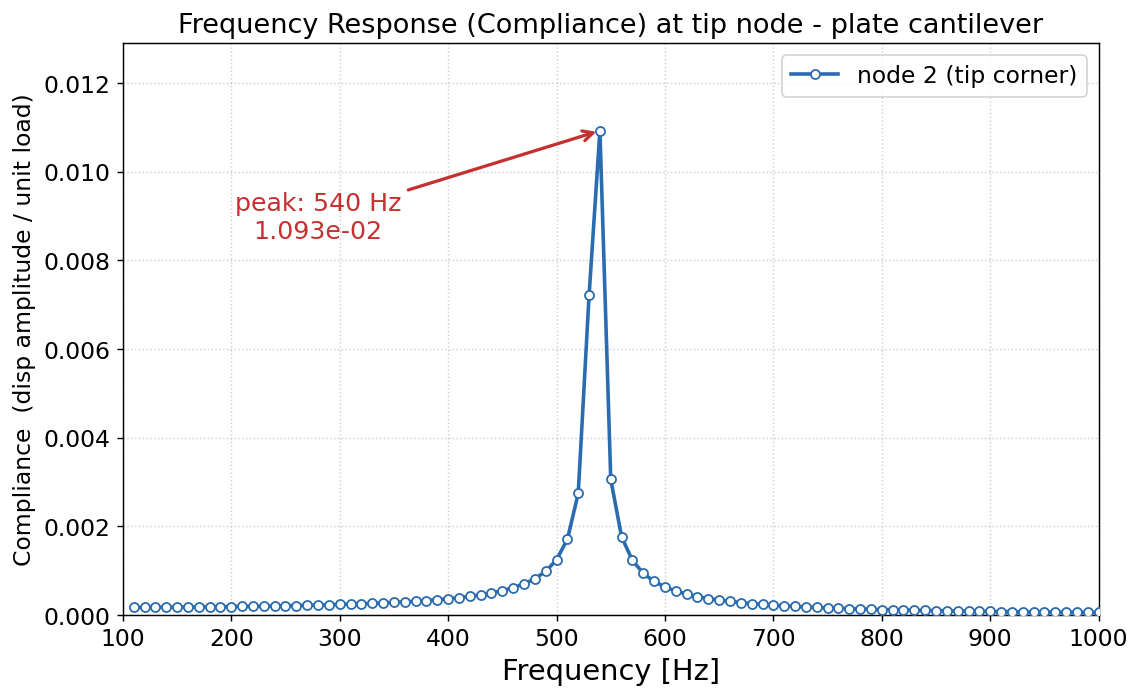

saved: docs/img/compliance.png


In [48]:
# ピーク（最大応答）を見つける
ipk = amp.index(max(amp))
fpk, apk = freq[ipk], amp[ipk]
print(f'peak: {fpk:.0f} Hz, {apk:.4e}')

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(9, 5.6), dpi=130)

ax.plot(freq, amp, '-o', color='#2b6cb0', lw=2, ms=5,
        mfc='white', mec='#2b6cb0', zorder=3, label='node 2 (tip corner)')

# ピークに矢印注釈（左側の空きスペースに置いて線・凡例と重ならないようにする）
ax.annotate(f'peak: {fpk:.0f} Hz\n{apk:.3e}',
            xy=(fpk, apk), xytext=(fpk - 260, apk * 0.82),
            fontsize=14, color='#c53030', ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='#c53030', lw=1.8))

ax.set_xlabel('Frequency [Hz]', fontsize=16)
ax.set_ylabel('Compliance  (disp amplitude / unit load)', fontsize=13)
ax.set_title('Frequency Response (Compliance) at tip node - plate cantilever',
             fontsize=15)
ax.set_xlim(100, 1000)
ax.set_ylim(0, apk * 1.18)   # ピーク上に余白 → 凡例と重ならない
ax.tick_params(labelsize=13)
ax.grid(True, ls=':', alpha=0.6)
ax.legend(fontsize=13, loc='upper right', frameon=True)

fig.tight_layout()
fig.savefig('docs/img/compliance.png')
plt.show()
print('saved: docs/img/compliance.png')